# i. Business Understanding

## i.i Blocker Fraud Company

* The Blocker Fraud Company is a company specialized in detecting fraud in financial transactions made through mobile devices. The company has a service called “Blocker Fraud” with no guarantee of blocking fraudulent transactions.

* And the business model of the company is of the Service type with the monetization made by the performance of the service provided, that is, the user pays a fixed fee on the success in detecting fraud in the customer's transactions.

### i.i.i Expansion Problem

Blocker Fraud Company is expanding in Brazil and to acquire customers more quickly, it has adopted a very aggressive strategy. The strategy works as follows:
1. The company will receive 25% of the value of each transaction that is truly detected as fraud.
1. The company will receive 5% of the value of each transaction detected as fraud, but the transaction is truly legitimate.
1. The company will return 100% of the value to the customer, for each transaction detected as legitimate, however the transaction is truly a fraud.

## i.ii The Challenge


You need to deliver to the CEO of Blocker Fraud Company a production model in which your access will be done via API, that is, customers will send their transactions via API so that your model classifies them as fraudulent or legitimate.

### i.ii.i Business Questions


1. What is the model's Precision and Accuracy?
1. How Reliable is the model in classifying transactions as legitimate or fraudulent?
1. What is the Expected Billing by the Company if we classify 100% of transactions with the model?
1. What is the Loss Expected by the Company in case of model failure?
1. What is the Profit Expected by the Blocker Fraud Company when using the model?

In [6]:
import warnings
warnings.filterwarnings('ignore')

import inflection
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import HTML

In [2]:
def jupyter_settings():
    %matplotlib inline

    sns.set(font_scale=1.6)
    sns.set_style("darkgrid")

    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 16
    
    display( HTML('<style>.container { width:100% !important; }</style>'))
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
jupyter_settings()

#  1.0 Data Description

## Loading Data 

In [13]:
fraud_df = pd.read_csv('../data/raw/fraud_0.1origbase.csv')

In [14]:
fraud_df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,283,CASH_IN,210329.84,C1159819632,3778062.79,3988392.64,C1218876138,1519266.60,1308936.76,0,0
1,132,CASH_OUT,215489.19,C1372369468,21518.00,0.00,C467105520,6345756.55,6794954.89,0,0
2,355,DEBIT,4431.05,C1059822709,20674.00,16242.95,C76588246,80876.56,85307.61,0,0
3,135,CASH_OUT,214026.20,C1464960643,46909.73,0.00,C1059379810,13467450.36,13681476.56,0,0
4,381,CASH_OUT,8858.45,C831134427,0.00,0.00,C579876929,1667180.58,1676039.03,0,0


In [5]:
fraud_df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
636257,351,CASH_OUT,28761.10,C742050657,0.0,0.00,C568407561,328534.52,357295.62,0,0
636258,184,CASH_OUT,167820.71,C561181412,62265.0,0.00,C1852953580,106429.48,274250.18,0,0
636259,35,PAYMENT,8898.12,C1773417333,30808.0,21909.88,M445701551,0.00,0.00,0,0
636260,277,CASH_OUT,176147.90,C1423233247,83669.0,0.00,C1328739120,0.00,176147.90,0,0
636261,304,CASH_OUT,95142.89,C874575079,0.0,0.00,C666451134,431380.07,526522.96,0,0


## 1.2 Columns

### 1.2.1 Column Descriptions

**step:** maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

**type:** CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

**amount:** amount of the transaction in local currency.

**nameOrig:** customer who started the transaction

**oldbalanceOrg:** initial balance before the transaction

**newbalanceOrig:** new balance after the transaction

**nameDest:** customer who is the recipient of the transaction

**oldbalanceDest:** initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

**newbalanceDest:** new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

**isFraud:** This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

**isFlaggedFraud:** The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

# 1.2.2 Columns Rename

In [16]:
cols_old = fraud_df.columns.tolist()

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

fraud_df.columns = cols_new

In [17]:
fraud_df.columns

Index(['step', 'type', 'amount', 'name_orig', 'oldbalance_org',
       'newbalance_orig', 'name_dest', 'oldbalance_dest', 'newbalance_dest',
       'is_fraud', 'is_flagged_fraud'],
      dtype='str')

## 1.3 Data Dimensions

In [9]:
print('Number of Rows: {}'.format(fraud_df.shape[0]))
print('Number of Cols: {}'.format(fraud_df.shape[1]))

Number of Rows: 636262
Number of Cols: 11


## 1.4 Data Types and Structure

In [10]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 636262 entries, 0 to 636261
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   step              636262 non-null  int64  
 1   type              636262 non-null  str    
 2   amount            636262 non-null  float64
 3   name_orig         636262 non-null  str    
 4   oldbalance_org    636262 non-null  float64
 5   newbalance_orig   636262 non-null  float64
 6   name_dest         636262 non-null  str    
 7   oldbalance_dest   636262 non-null  float64
 8   newbalance_dest   636262 non-null  float64
 9   is_fraud          636262 non-null  int64  
 10  is_flagged_fraud  636262 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 70.6 MB


## 1.5 Check NA(Missing values)

In [11]:
fraud_df.isna().mean().sort_values(ascending=False) * 100

step                0.0
type                0.0
amount              0.0
name_orig           0.0
oldbalance_org      0.0
newbalance_orig     0.0
name_dest           0.0
oldbalance_dest     0.0
newbalance_dest     0.0
is_fraud            0.0
is_flagged_fraud    0.0
dtype: float64

No missing value --> No imputation required.

## 1.6 Change Data Type

In [18]:
fraud_df_eda=fraud_df.copy()

In [19]:
fraud_df_eda['is_fraud'] = fraud_df_eda['is_fraud'].map({1: 'yes', 0: 'no'})
fraud_df_eda['is_flagged_fraud'] = fraud_df_eda['is_flagged_fraud'].map({1: 'yes', 0: 'no'})

## 1.7 Split numeric/categorical features

In [21]:
num_attributes = fraud_df_eda.select_dtypes(exclude='object')
cat_attributes = fraud_df_eda.select_dtypes(include='object')

### 1.7.1 Numerical Attributes

In [22]:
describe = num_attributes.describe().T

describe['range'] = (num_attributes.max() - num_attributes.min()).tolist()
describe['variation coefficient'] = (num_attributes.std() / num_attributes.mean()).tolist()
describe['skew'] = num_attributes.skew().tolist()
describe['kurtosis'] = num_attributes.kurtosis().tolist()

describe

,count,mean,std,min,25%,50%,75%,max,range,variation coefficient,skew,kurtosis
step,636262.0,2.429319e+02,1.423309e+02,1.0,155.000,238.000,3.340000e+02,7.420000e+02,7.410000e+02,0.585888,0.375052,0.324437
amount,636262.0,1.800585e+05,6.069714e+05,0.0,13407.425,74815.770,2.084988e+05,5.722962e+07,5.722962e+07,3.370967,29.577107,1546.661043
oldbalance_org,636262.0,8.317937e+05,2.885636e+06,0.0,0.000,14239.000,1.072998e+05,4.368662e+07,4.368662e+07,3.469173,5.243428,32.766036
newbalance_orig,636262.0,8.528354e+05,2.921296e+06,0.0,0.000,0.000,1.435652e+05,4.367380e+07,4.367380e+07,3.425393,5.173614,31.932547
oldbalance_dest,636262.0,1.096212e+06,3.375389e+06,0.0,0.000,131539.745,9.384820e+05,3.551855e+08,3.551855e+08,3.079138,20.622388,1074.335293
newbalance_dest,636262.0,1.221809e+06,3.656213e+06,0.0,0.000,214712.725,1.109230e+06,3.555534e+08,3.555534e+08,2.992460,19.623903,928.694204


### Distribution Insights

* All monetary features (amount, oldbalance_org, newbalance_orig, oldbalance_dest, newbalance_dest) exhibit extremely high coefficients of variation (≈ 3.0+), indicating significant heterogeneity and wide dispersion in transaction values.

* The step variable shows moderate variability (CV ≈ 0.59), indicating that transactions are distributed across time but are relatively more stable compared to financial attributes.

* All monetary variables are highly positively skewed (skewness > 5 in most cases), suggesting that most transactions occur at low values, while a small number of transactions involve extremely large amounts.

* Extremely high kurtosis values (e.g., amount ≈ 1546) indicate heavy-tailed distributions and the presence of extreme outliers.

* The median of newbalance_orig is 0, implying that at least half of the transactions fully deplete the origin account balance, consistent with transfer or cash-out behavior.

* Several destination balance features also show a high frequency of zero values, indicating sparse account activity patterns.

### 1.7.2 Categorical Attributes

In [23]:
cat_attributes.describe()

,type,name_orig,name_dest,is_fraud,is_flagged_fraud
count,636262,636262,636262,636262,636262
unique,5,636171,457224,2,2
top,CASH_OUT,C21821244,C1219369531,no,no
freq,224216,2,14,635441,636260


### Categorical Feature Insights

* CASH_OUT is the most frequent transaction type, indicating that withdrawal-like transactions dominate the dataset.

* name_orig and name_dest exhibit extremely high cardinality, with nearly unique values for most records. This makes  one-hot encoding infeasible due to high dimensionality and sparsity. These fields behave more like transaction identifiers than predictive categorical variables.

* The number of unique destination accounts is lower than origin accounts, suggesting that certain accounts act as frequent receivers, potentially indicating hub-like behavior in transaction flow.

* Due to the nature of account identifiers, alternative encoding strategies (such as frequency encoding or feature exclusion) are more appropriate than one-hot encoding.
 
* A significant mismatch exists between is_fraud and is_flagged_fraud, indicating that the rule-based system fails to capture the majority of fraudulent transactions, resulting in extremely low detection effectiveness.

###  1.8 Feature Transformation

In [24]:
fraud_df_eda['step_days'] = fraud_df_eda['step'].apply(lambda i: i/24)
fraud_df_eda['step_weeks'] = fraud_df_eda['step'].apply(lambda i: i/(24*7))

# difference between initial balance before the transaction and new balance after the transaction
fraud_df_eda['diff_new_old_balance'] = fraud_df_eda['newbalance_orig'] - fraud_df_eda['oldbalance_org']

# difference between initial balance recipient before the transaction and new balance recipient after the transaction.
fraud_df_eda['diff_new_old_dest'] = fraud_df_eda['newbalance_dest'] - fraud_df_eda['oldbalance_dest']

# name orig and name dest
fraud_df_eda['name_orig'] = fraud_df_eda['name_orig'].apply(lambda i: i[0])
fraud_df_eda['name_dest'] = fraud_df_eda['name_dest'].apply(lambda i: i[0])

In [25]:
df3=fraud_df_eda.copy()

## 2.0 Analysis

### 2.1 Univariate Analysis

Response(Target) Variable

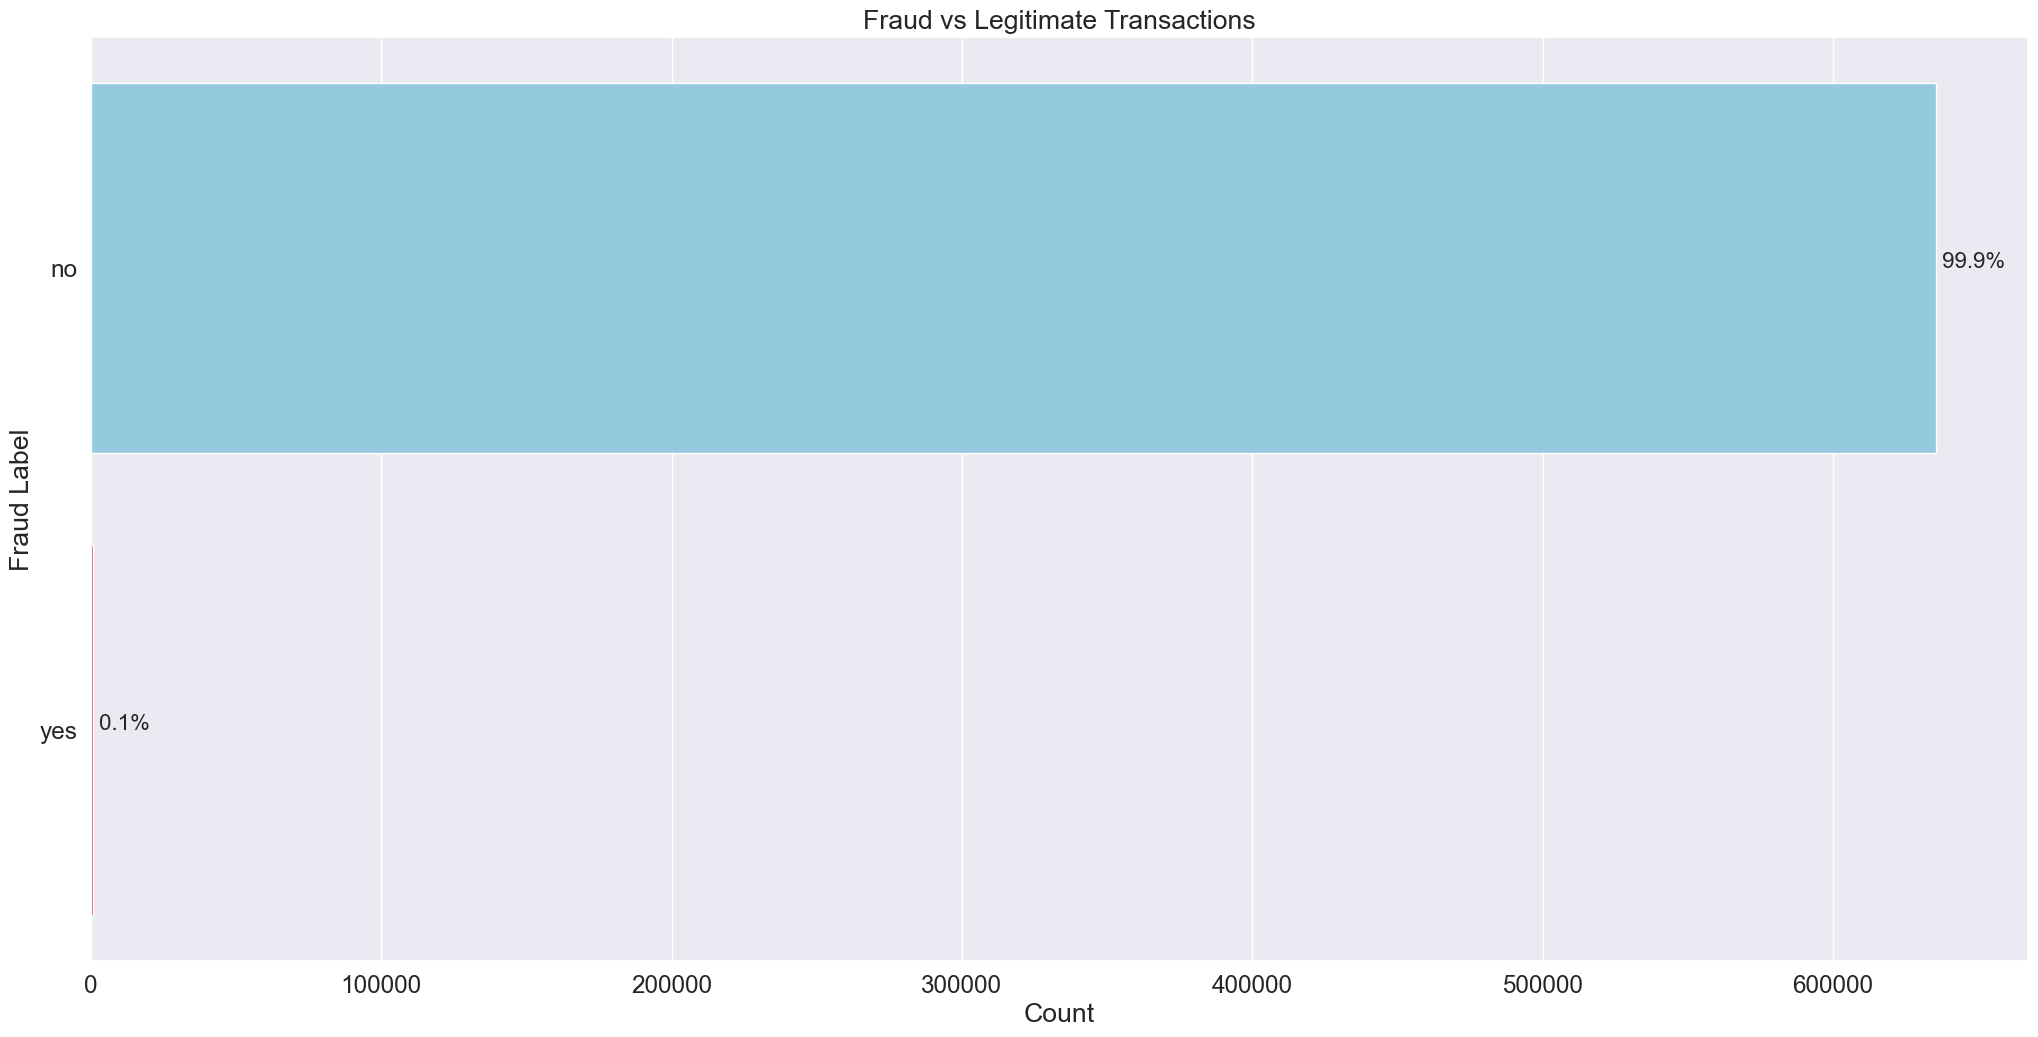

In [26]:
ax = sns.countplot(y='is_fraud', data=df3,palette=['skyblue','red'])

total = df3['is_fraud'].size
for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Count")
plt.ylabel("Fraud Label")
plt.show()

Numerical Variables

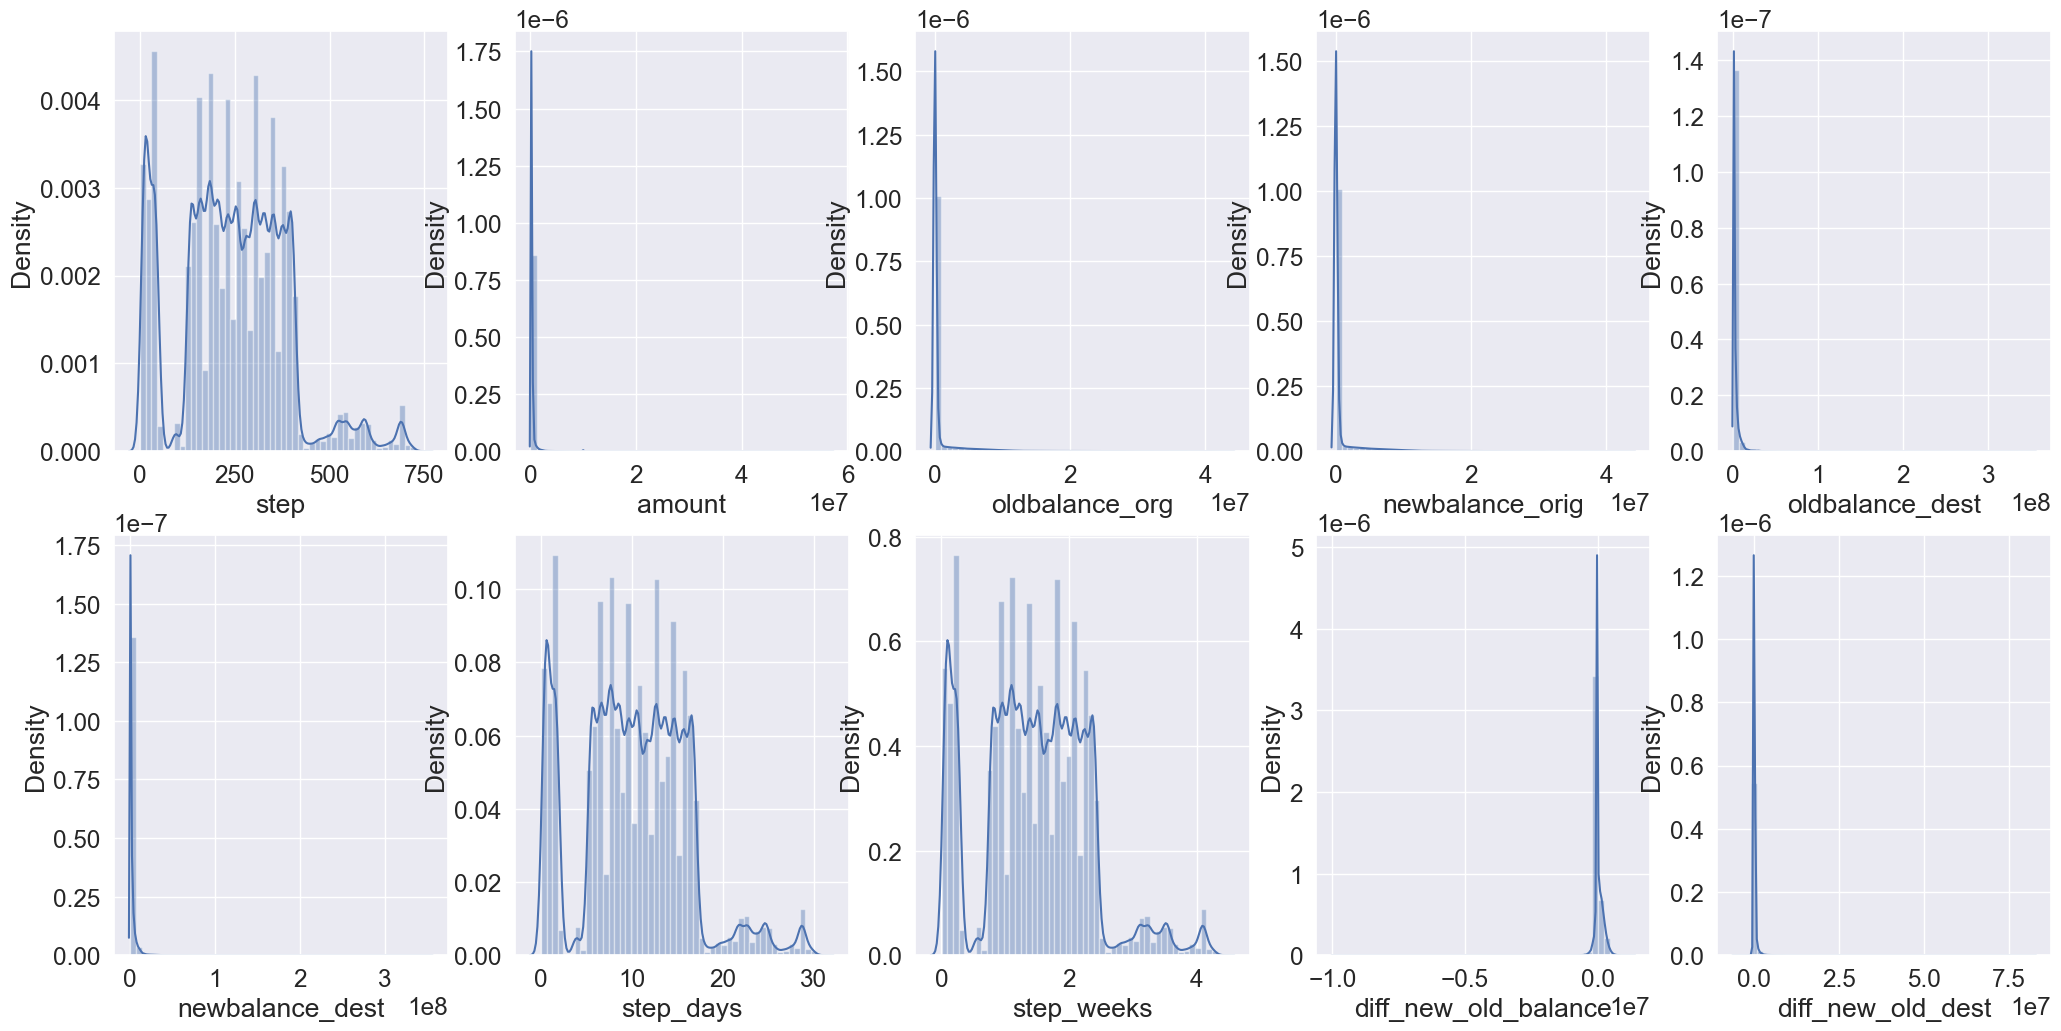

In [27]:
num_attributes = df3.select_dtypes(exclude='object')
columns = num_attributes.columns.tolist()
j = 1

for column in columns:
    plt.subplot(2, 5, j)
    sns.distplot(num_attributes[column]);
    
    j += 1

Boxplot (Outliers detection)

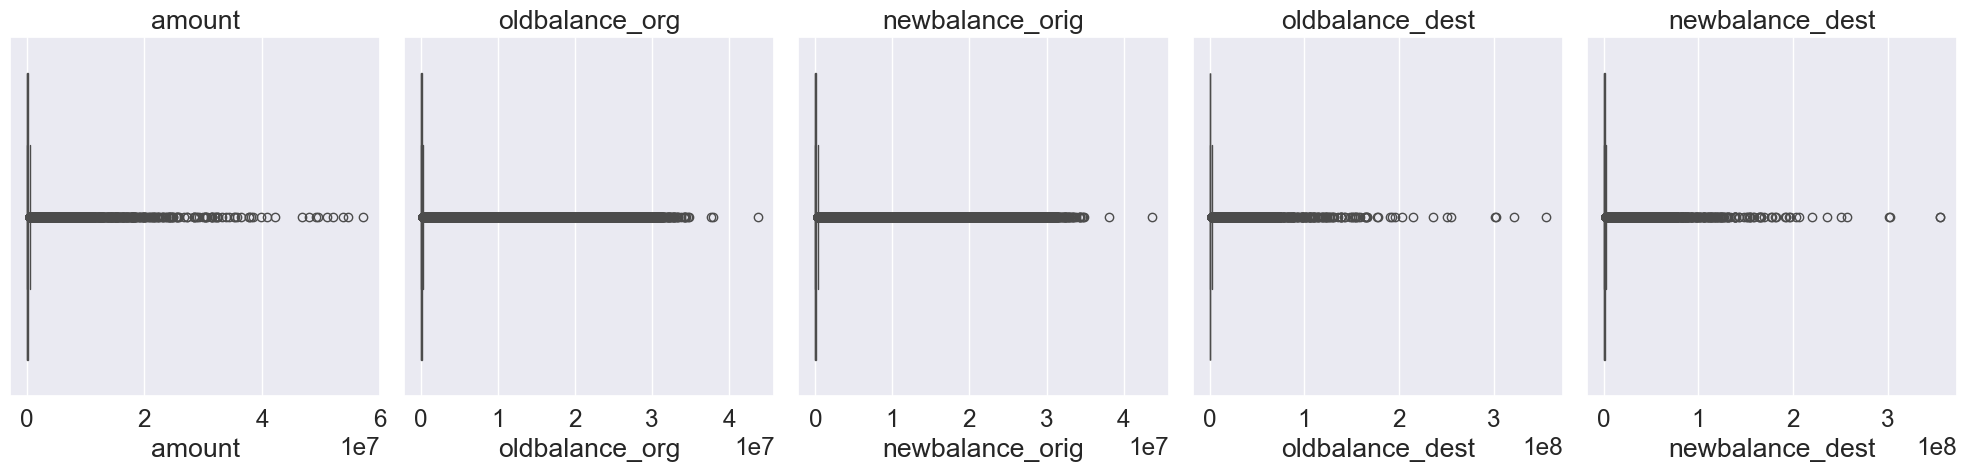

In [28]:
plt.figure(figsize=(20,5))

j = 1

data = df3[['amount',
            'oldbalance_org',
            'newbalance_orig',
            'oldbalance_dest',
            'newbalance_dest']]

columns = data.columns.tolist()

for column in columns:
    plt.subplot(1, 5, j)
    sns.boxplot(x=data[column])

    plt.title(column)
    j += 1

plt.tight_layout()
plt.show()

Categorical Variables

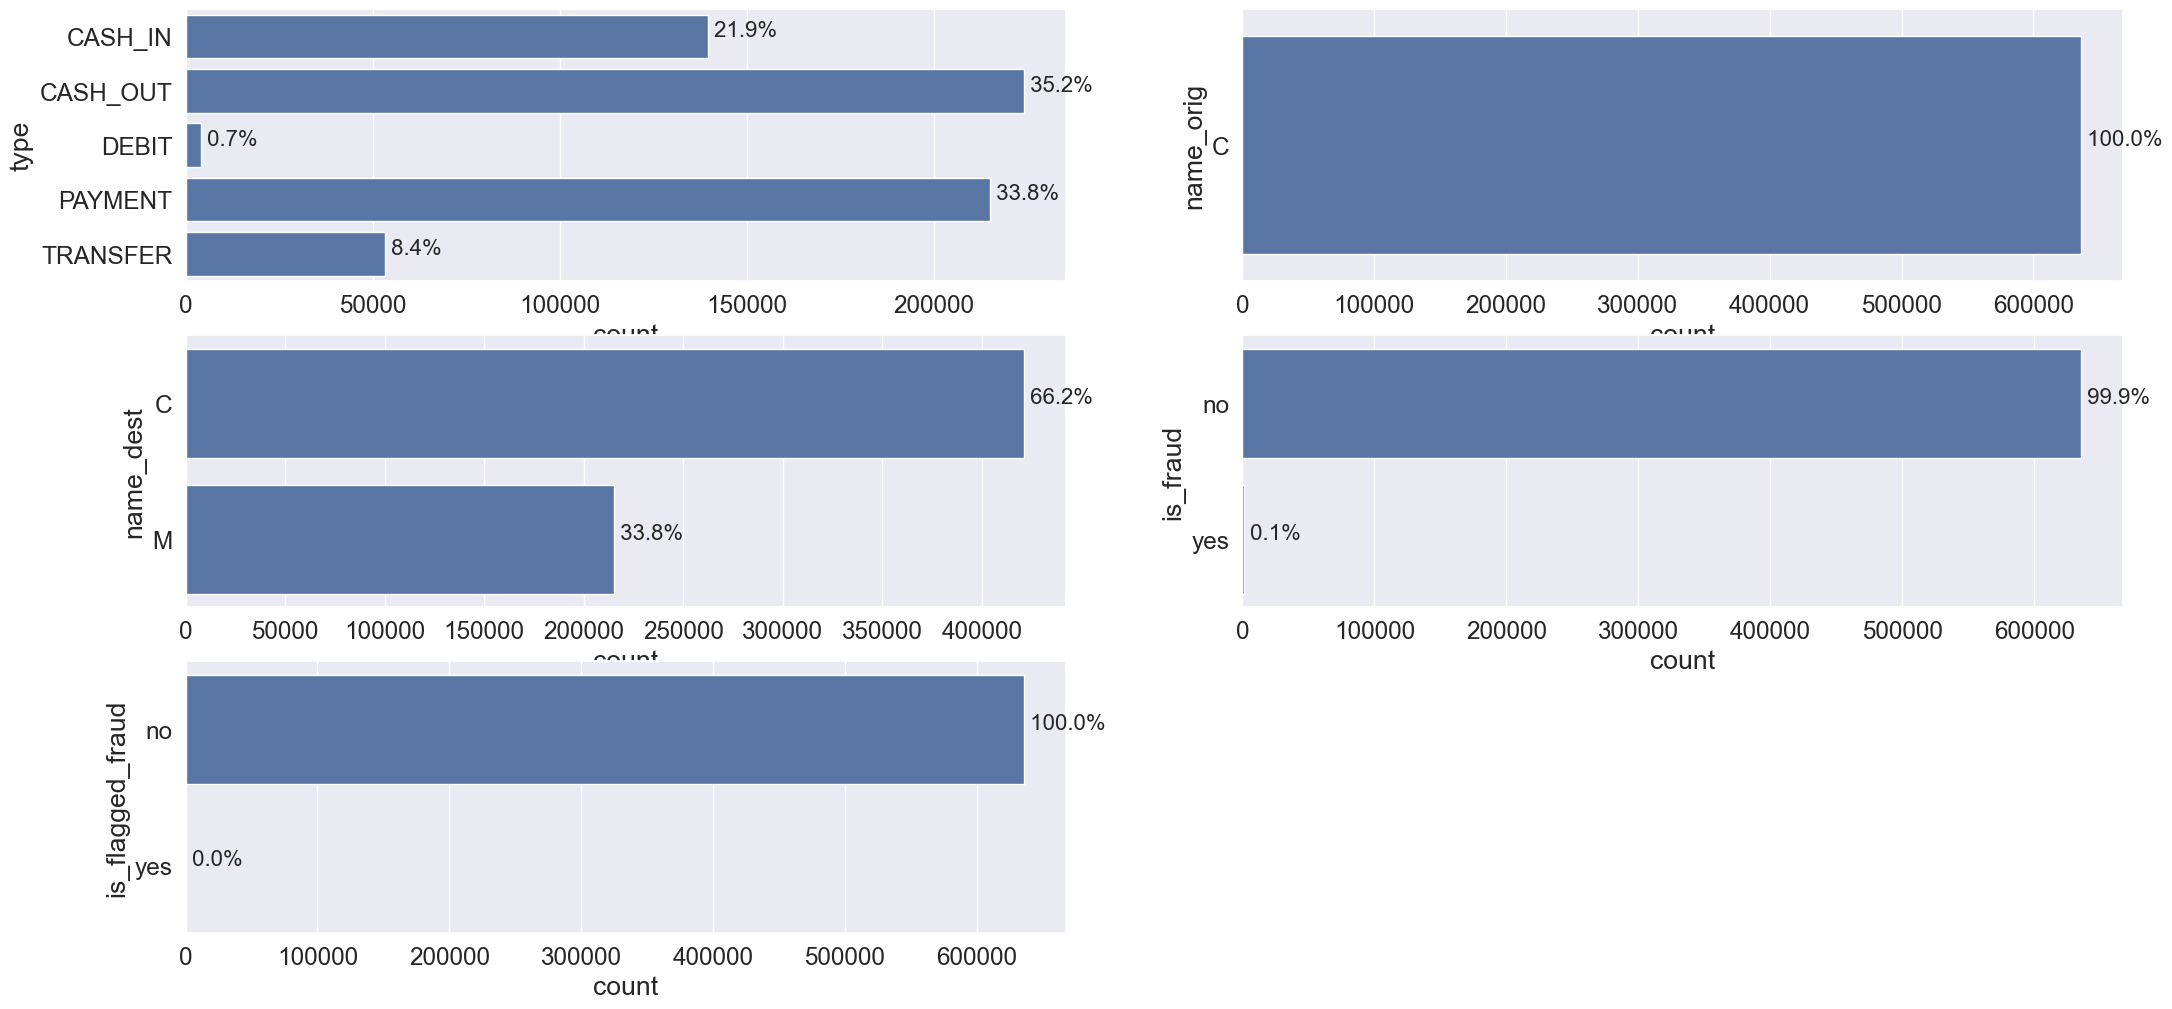

In [29]:
cat_attributes = df3.select_dtypes(include='object')
columns = cat_attributes.columns.tolist()
j = 1

for column in columns:
    plt.subplot(3, 2, j)
    ax = sns.countplot(y=column, data=cat_attributes)
    
    total = cat_attributes[column].size
    for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))
    
    j += 1

### 2.2 Bivariate Analysis

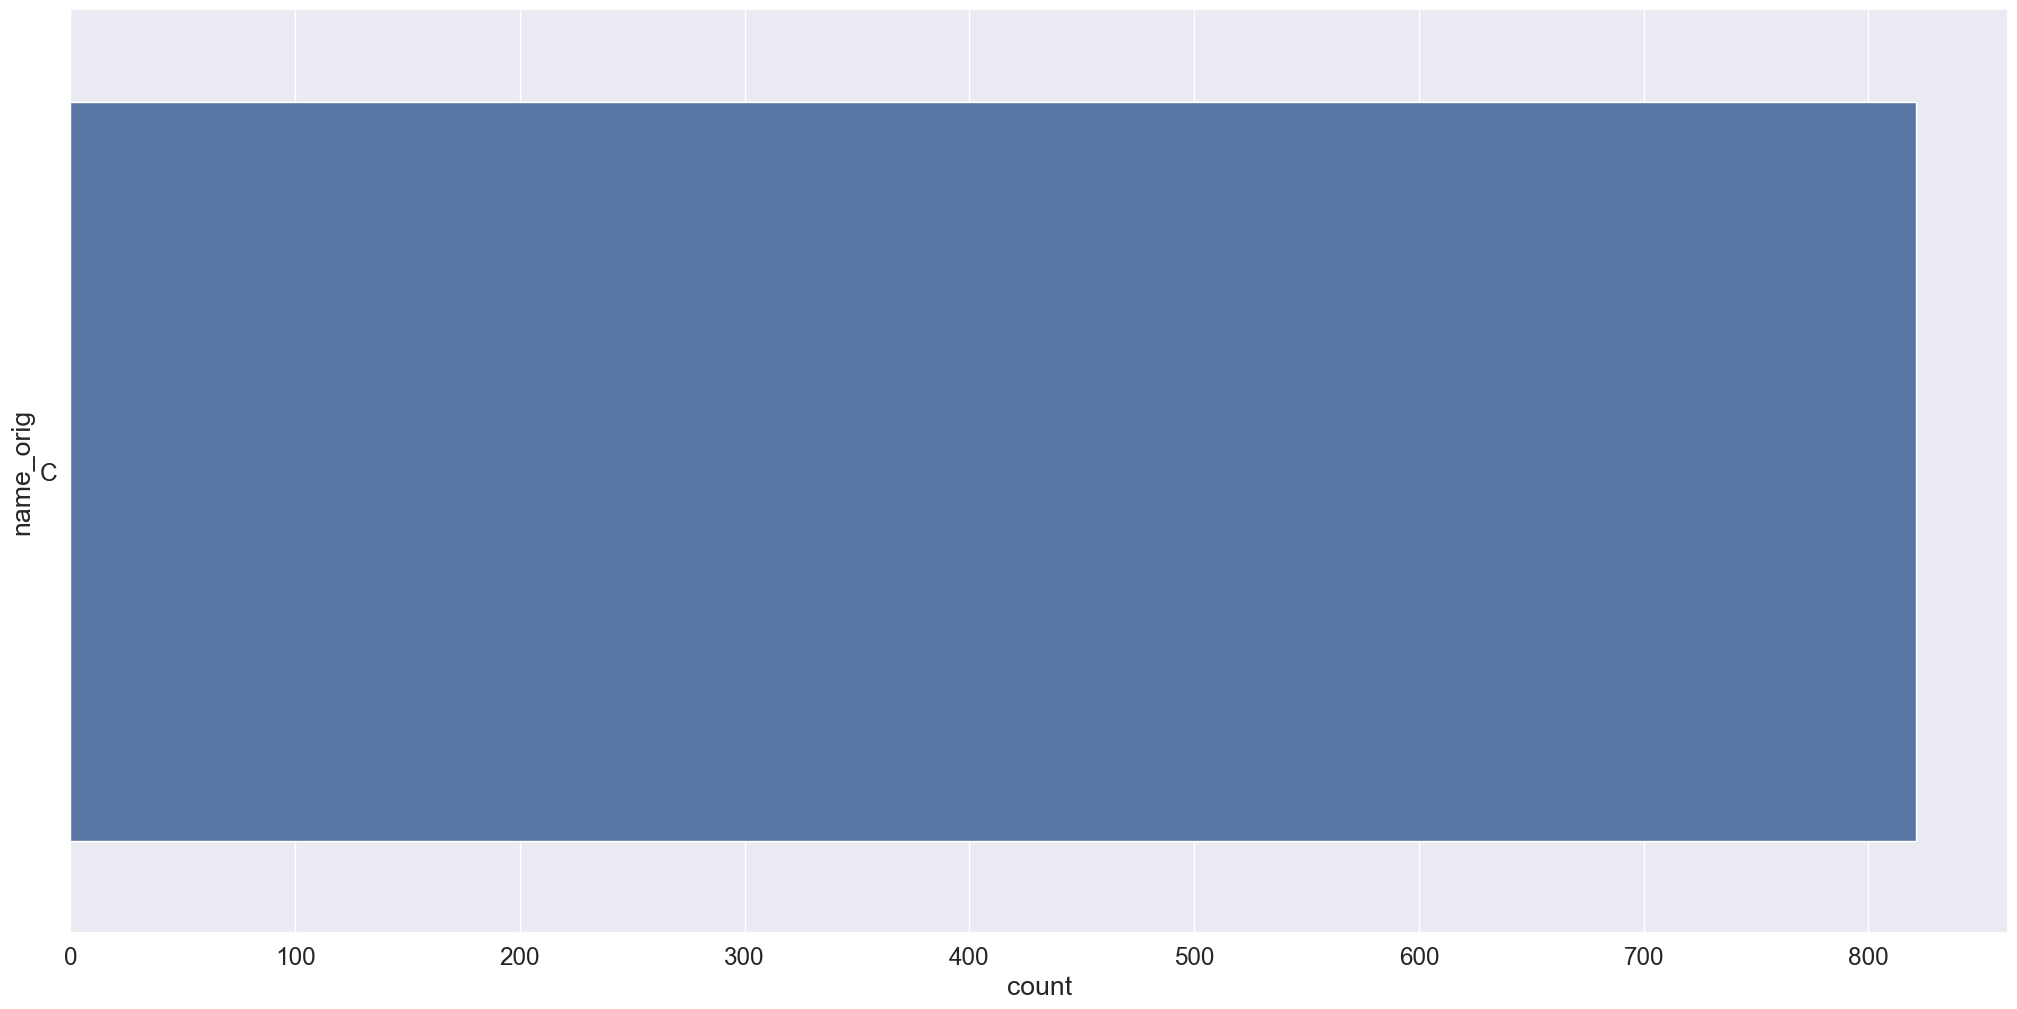

In [30]:
aux1 = df3[df3['is_fraud'] == 'yes']
sns.countplot(y='name_orig', data=aux1);

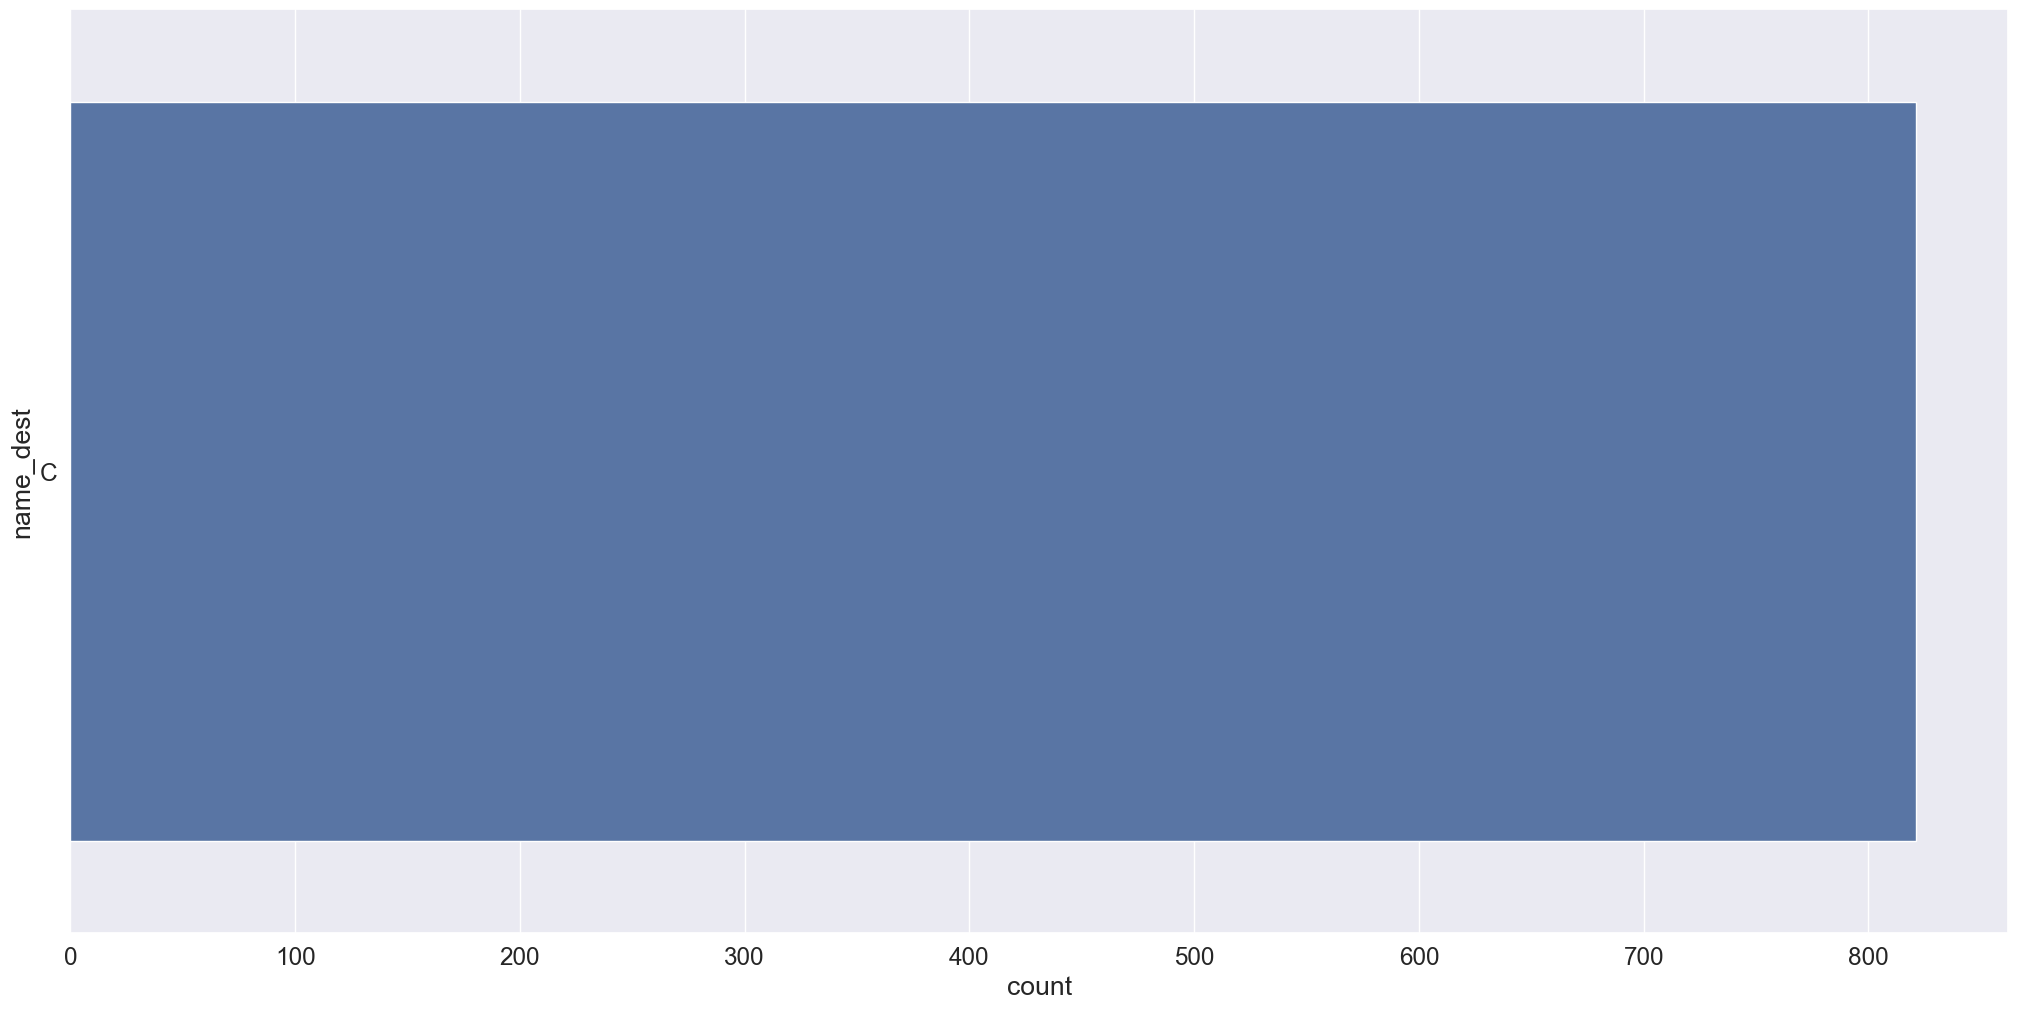

In [31]:
sns.countplot(y='name_dest', data=aux1);

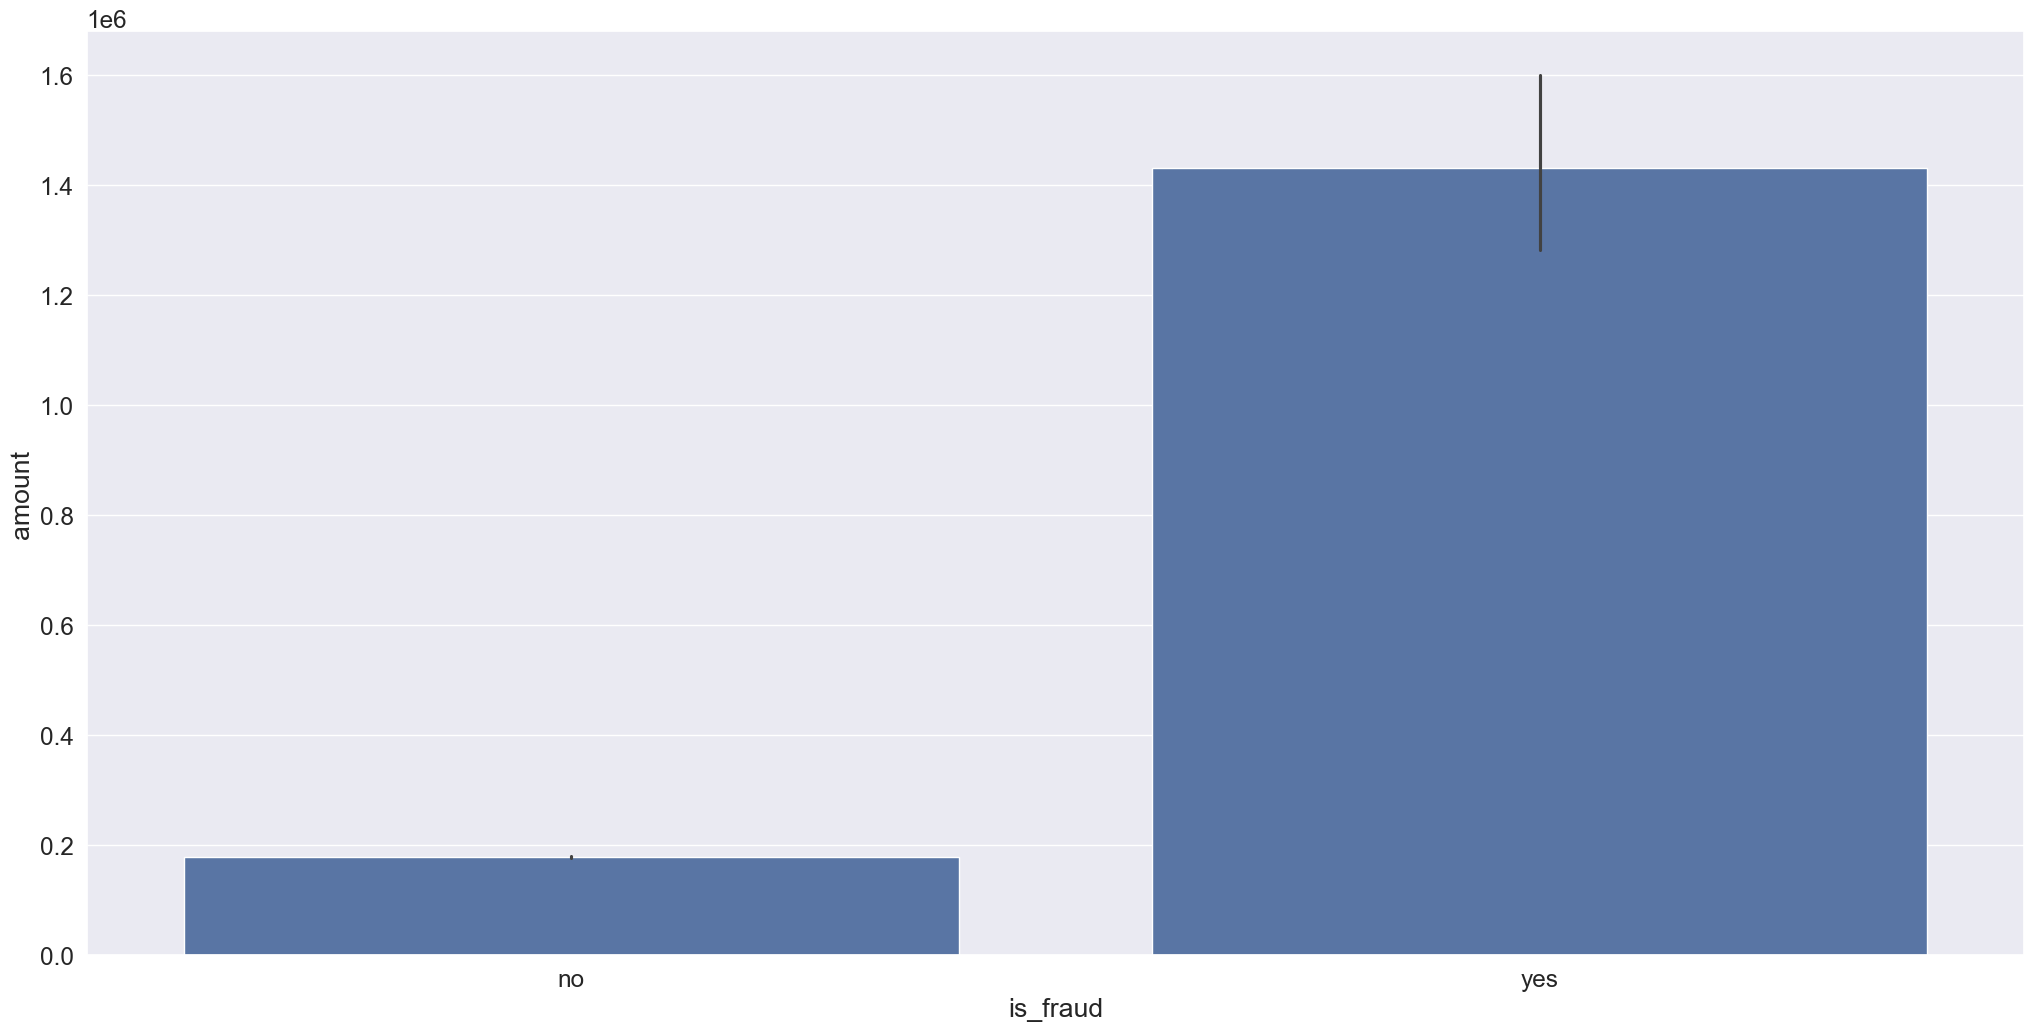

In [32]:
sns.barplot(y='amount', x='is_fraud', data=df3);

The fraud transaction occours in transfer and cash-out type. However they're almost the same value.

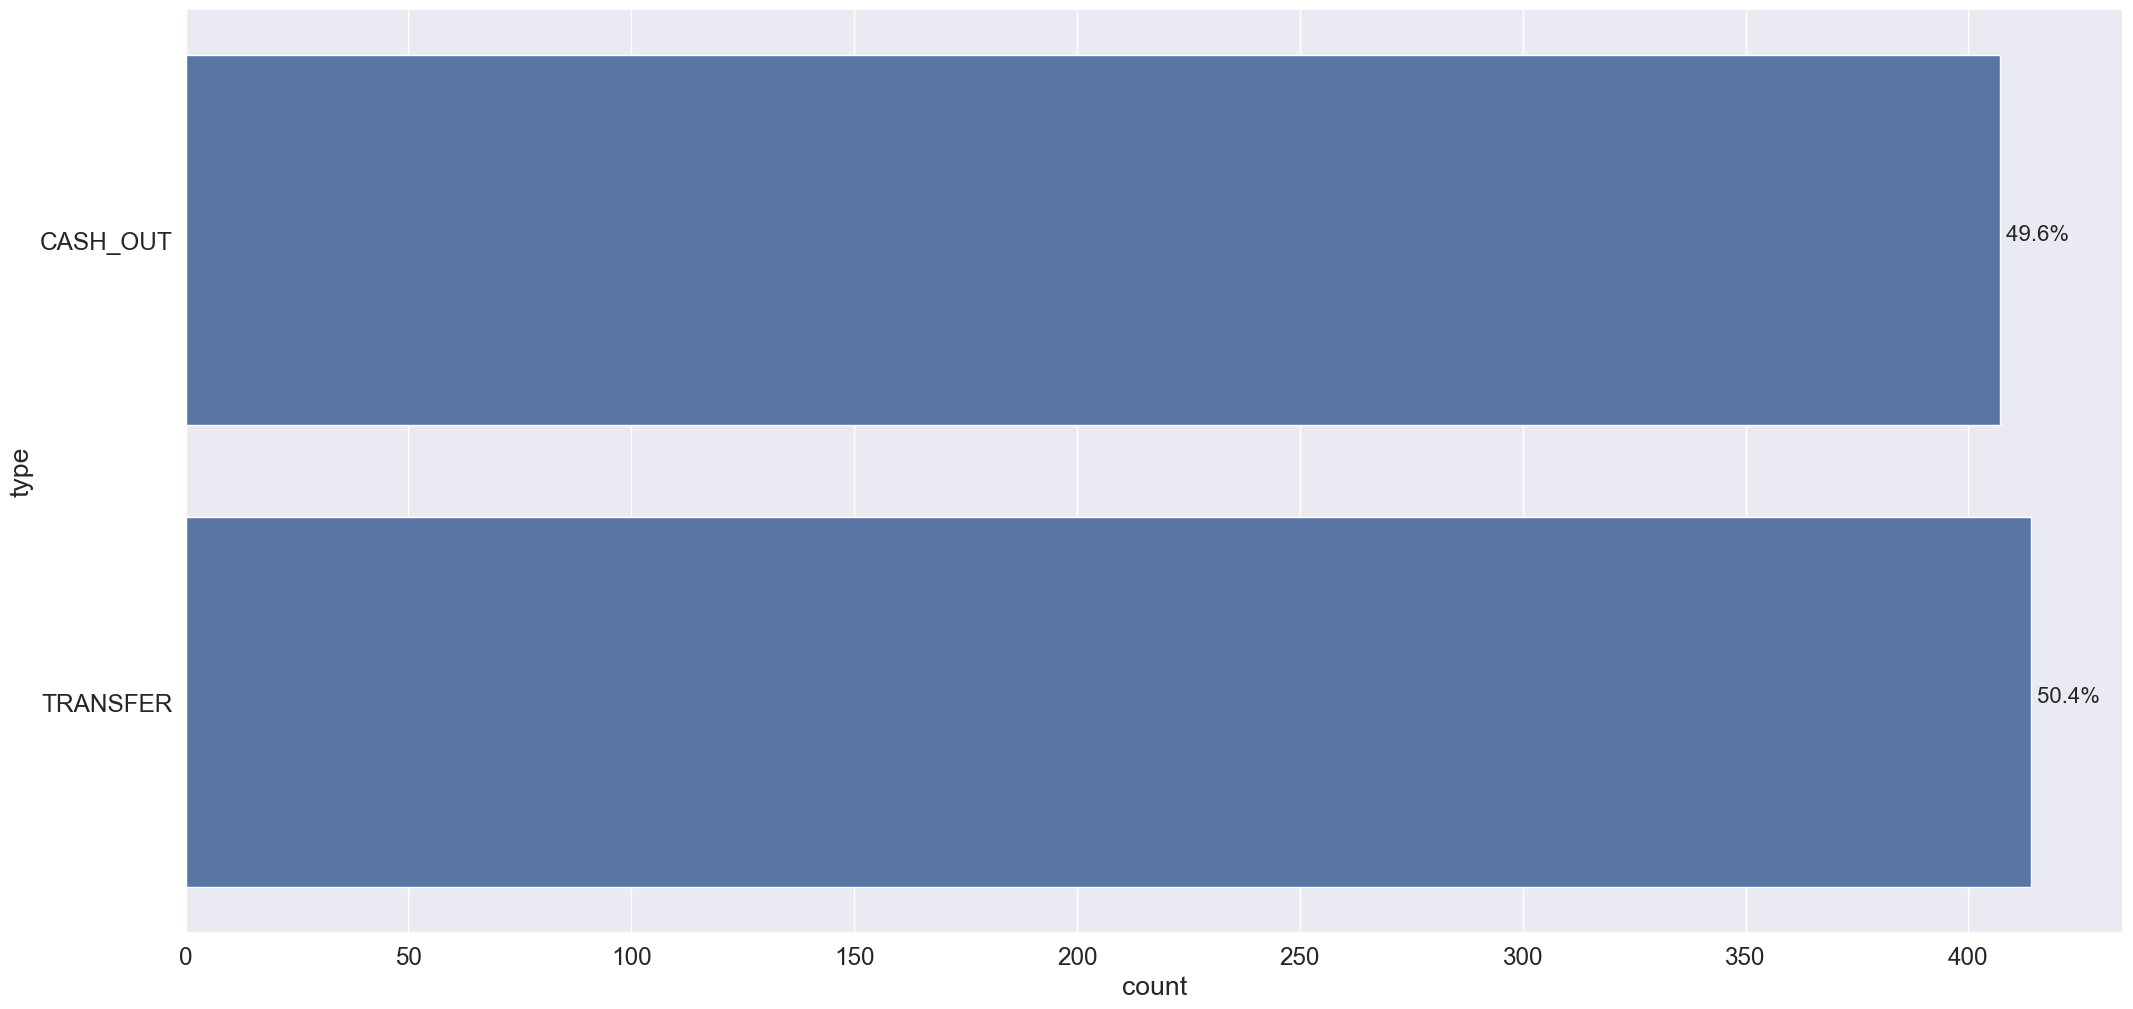

In [33]:
aux1 = df3[df3['is_fraud'] == 'yes']
ax = sns.countplot(y='type', data=aux1)

total = aux1['type'].size
for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))

To see the complete transaction-type

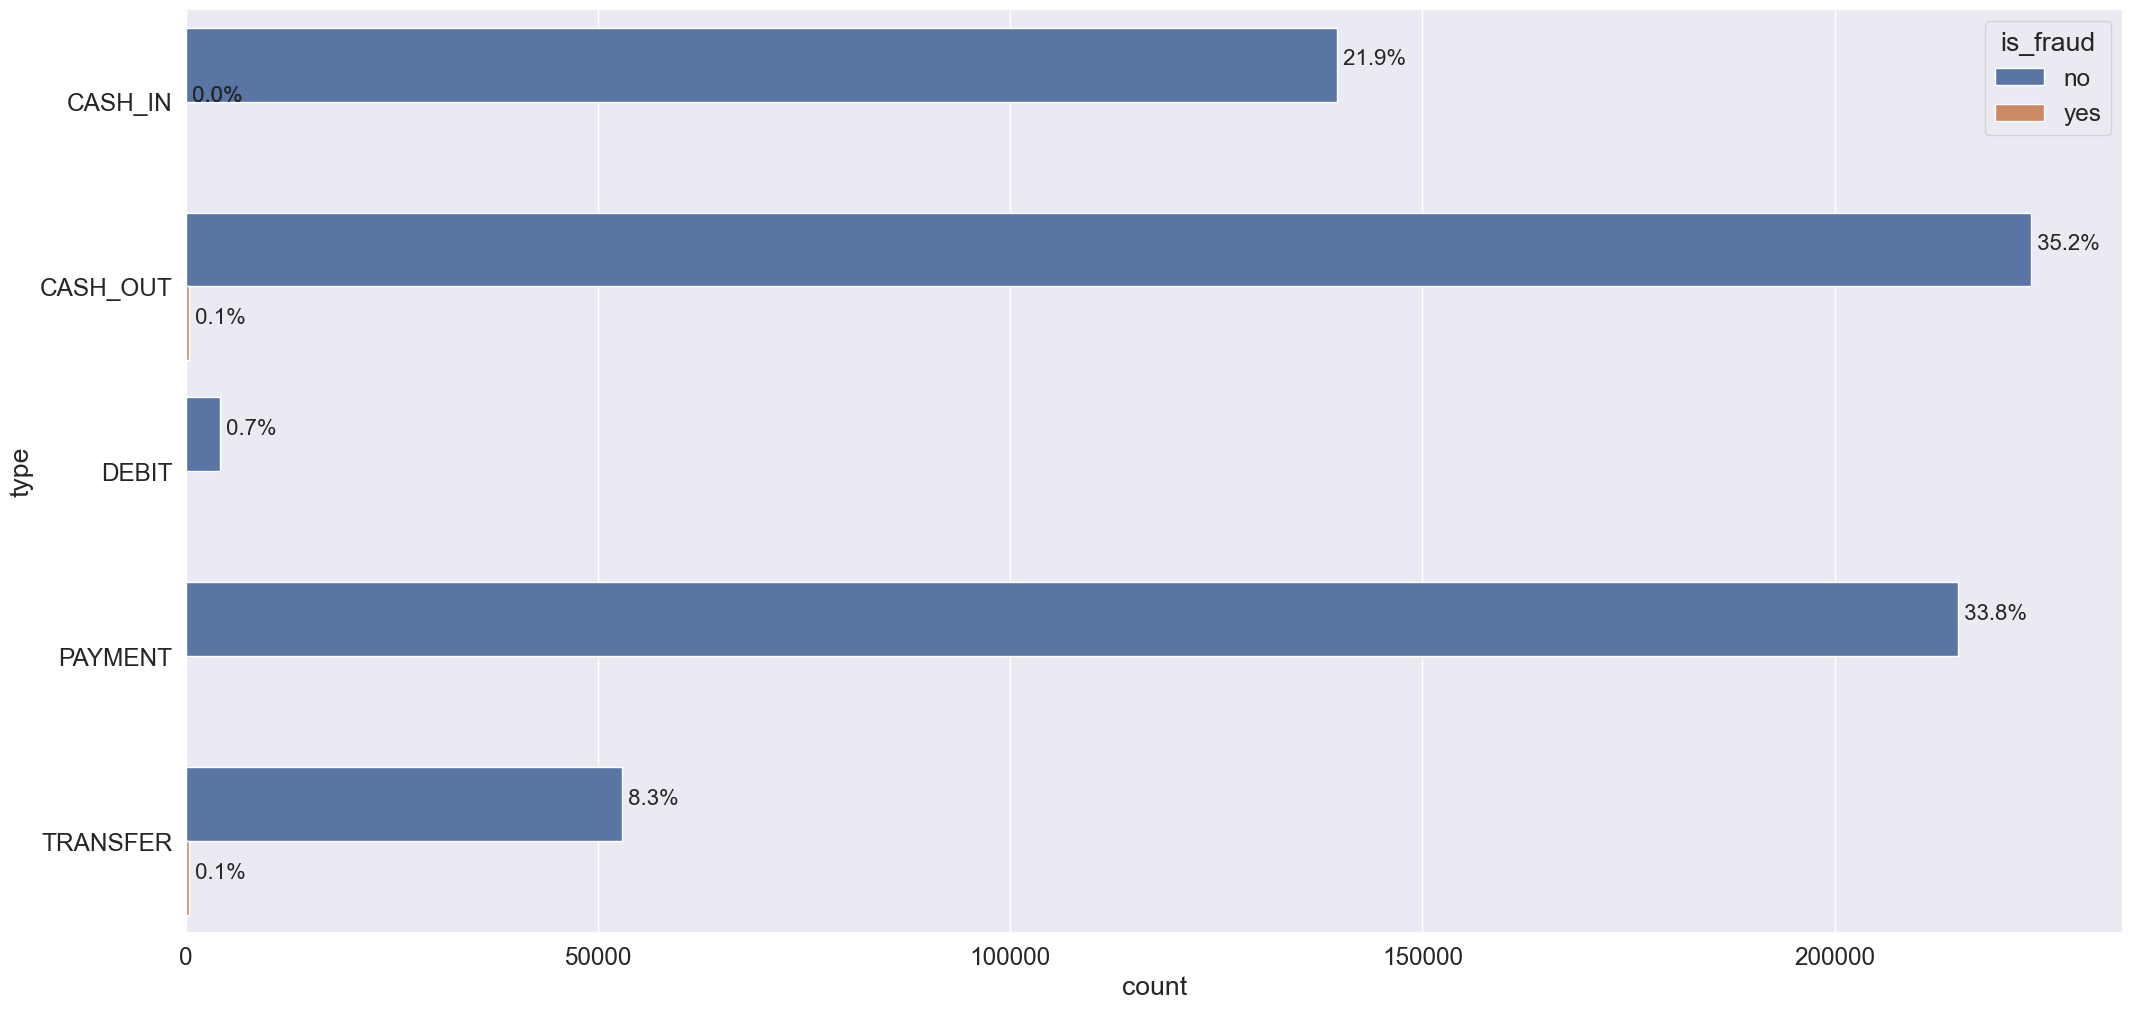

In [34]:
ax = sns.countplot(y='type', hue='is_fraud', data=df3)

total = df3['type'].size
for p in ax.patches:
        percentage = ' {:.1f}%'.format(100 * p.get_width()/total)
        x = p.get_x() + p.get_width() + 0.02
        y = p.get_y() + p.get_height()/2
        ax.annotate(percentage, (x, y))

TRANSFER transactions have the highest average value, followed by CASH_OUT and CASH_IN.

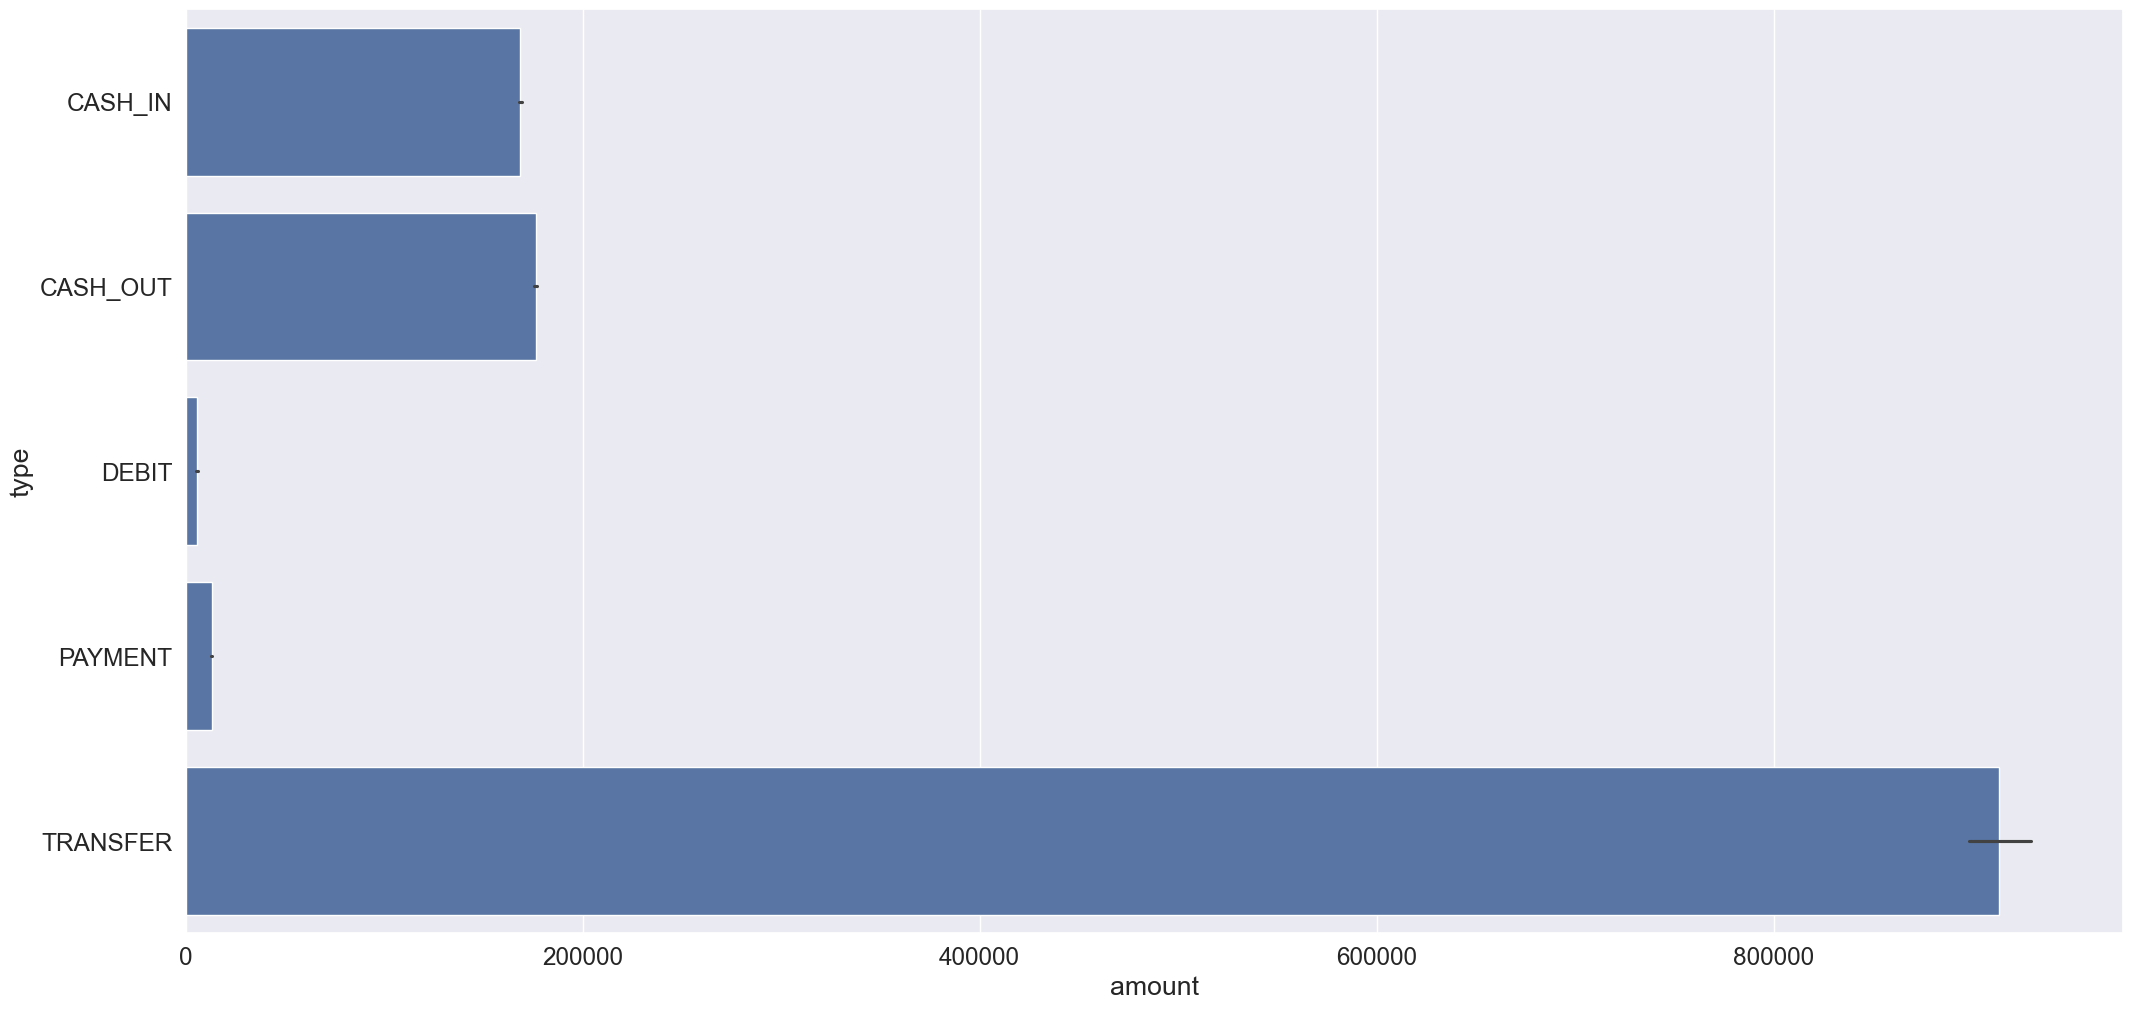

In [35]:
ax = sns.barplot(y='type', x='amount', data=df3)

total = df3['type'].size


Fraud amount does not significantly change over time. Fraudulent transactions occur throughout the observation period with similar transaction values.

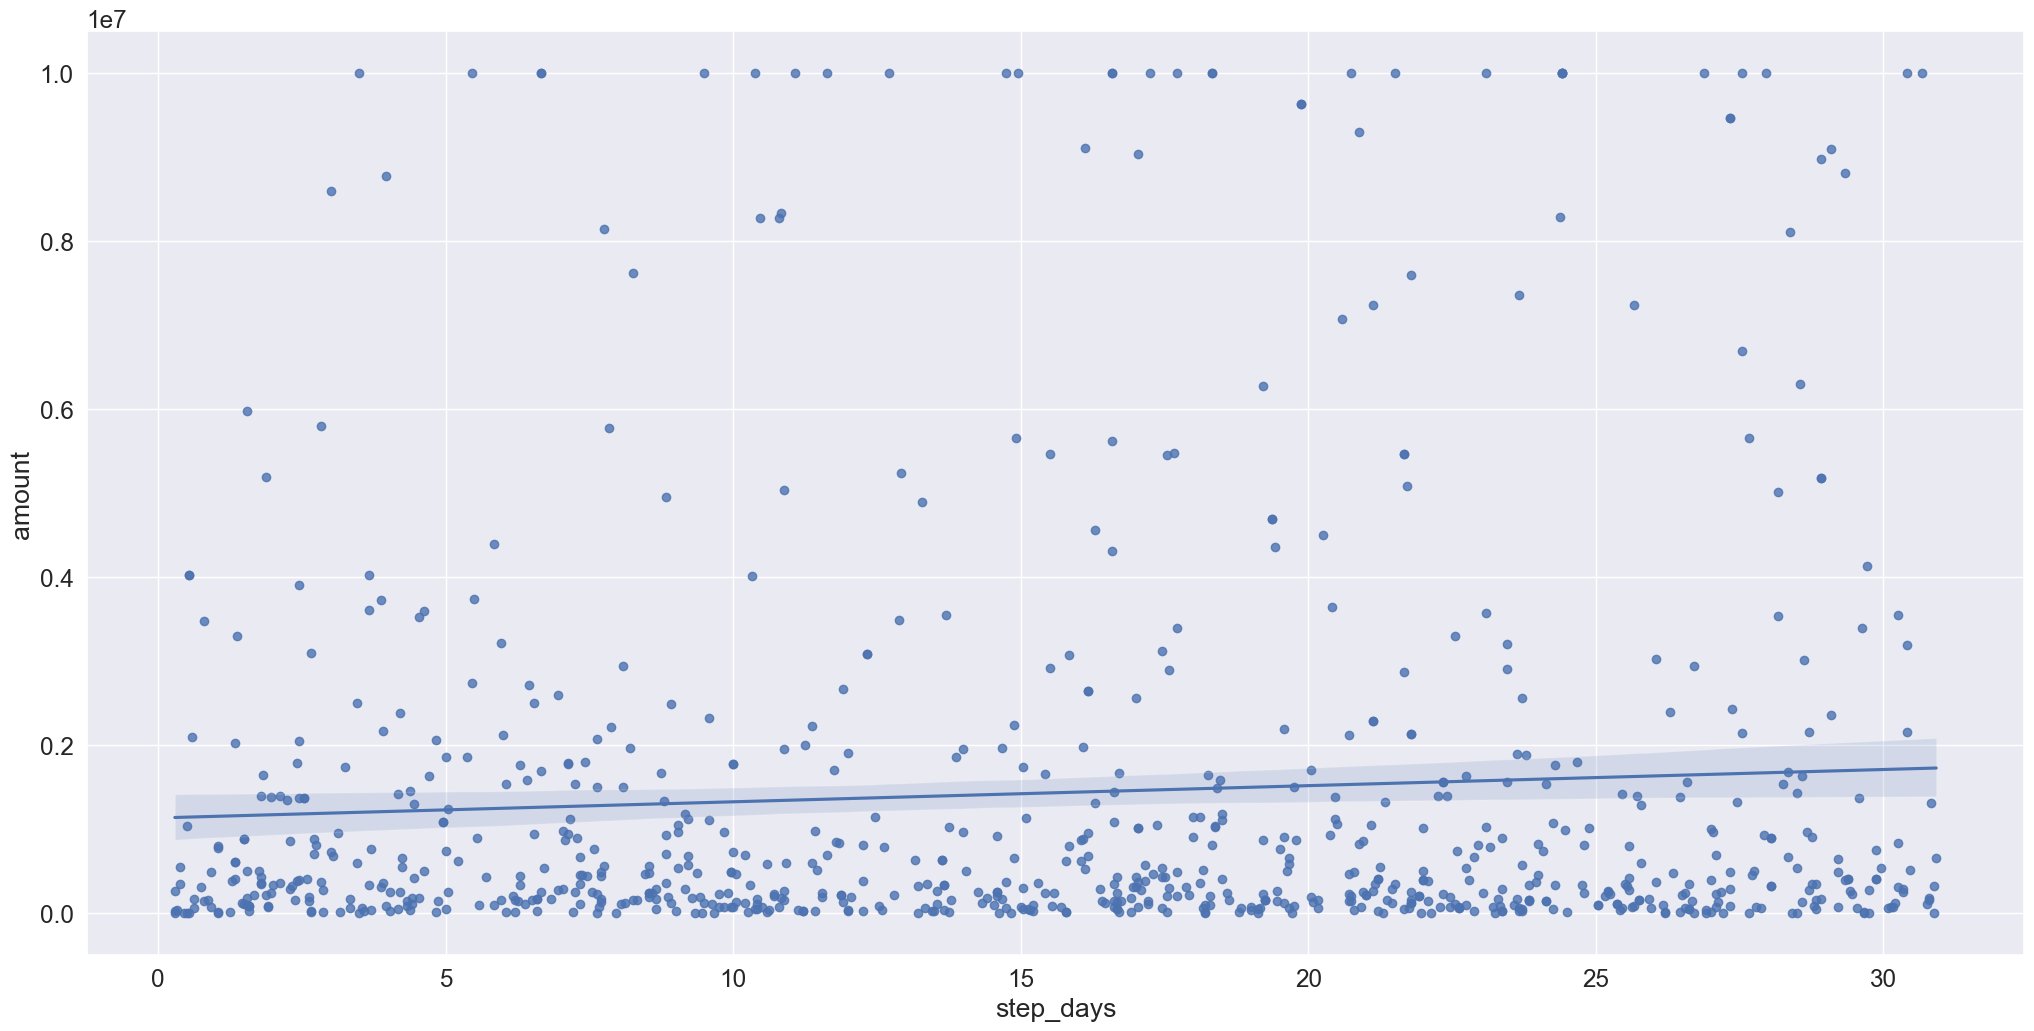

In [36]:
aux1 = df3[df3['is_fraud'] == 'yes']
sns.regplot(x='step_days', y='amount', data=aux1);

### 2.3 Multivariate Analysis

Numerical Variables

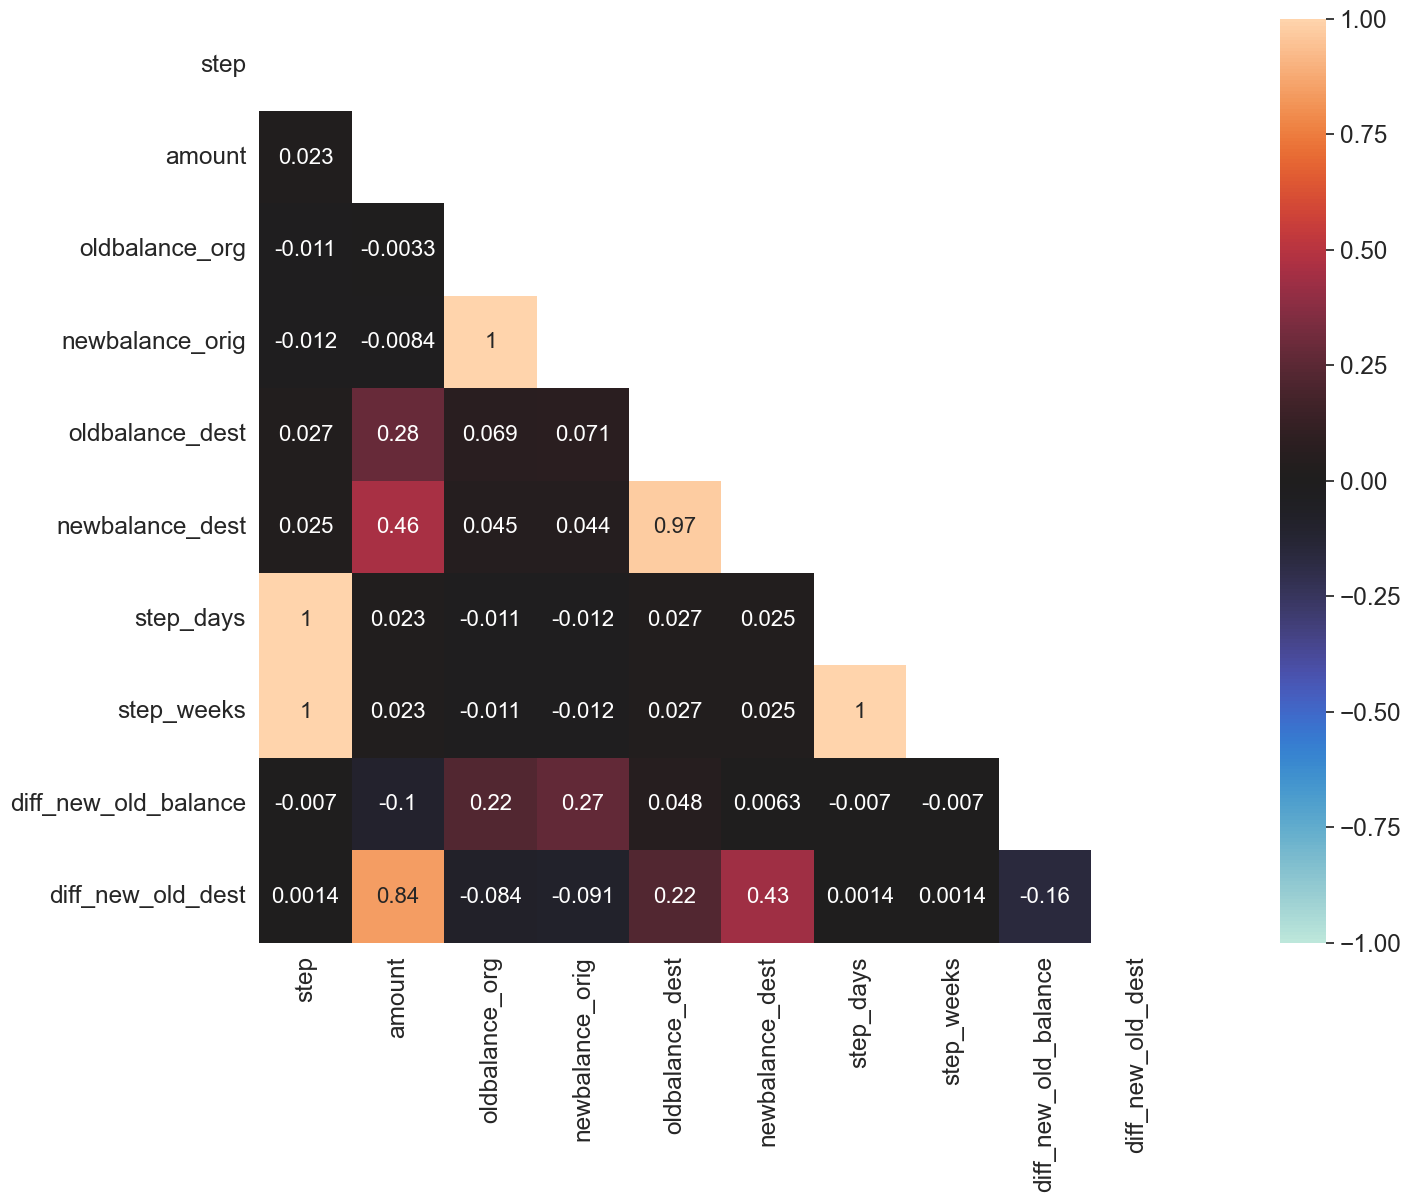

In [37]:
corr = num_attributes.corr()

mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
    ax = sns.heatmap(corr, annot=True, mask=mask, vmin=-1, center=0, vmax=1, square=True)

Categorical Variables

In [39]:
def calcCramerV(x, y):
    cm = pd.crosstab(x, y).values
    n = cm.sum()
    r, k = cm.shape
    
    chi2 = stats.chi2_contingency(cm)[0]
    chi2corr = max(0, chi2 - (k-1)*(r-1)/(n-1))
    
    kcorr = k - (k-1)**2/(n-1)
    rcorr = r - (r-1)**2/(n-1)
    
    return np.sqrt((chi2corr/n) / (min(kcorr-1, rcorr-1)))

In [40]:
dict_corr = {}
columns = cat_attributes.columns.tolist()

for column in columns:
    dict_corr[column] = {}
    
    for column2 in columns:
        dict_corr[column][column2] = calcCramerV(cat_attributes[column], cat_attributes[column2])
        
corr = pd.DataFrame(dict_corr)

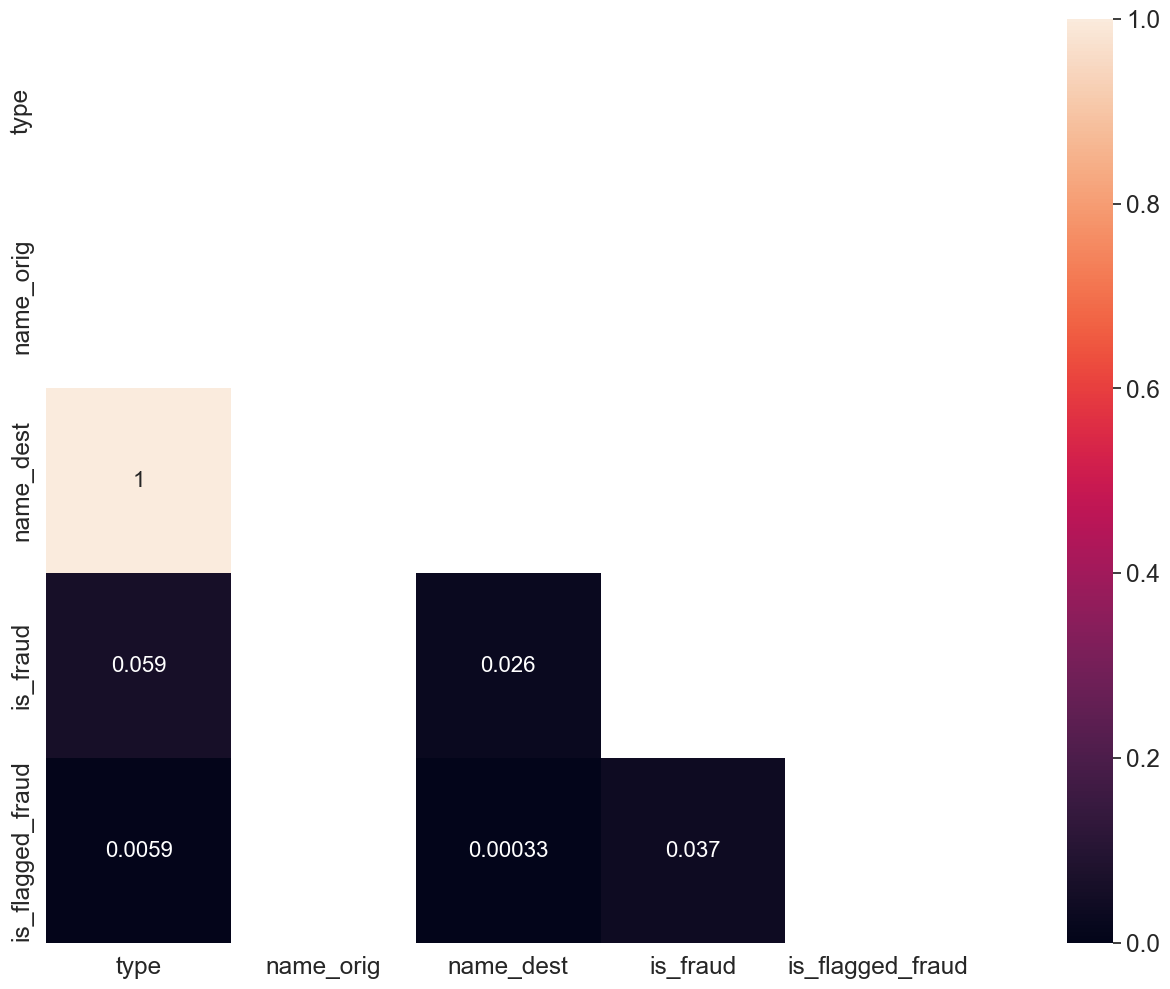

In [41]:
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
    ax = sns.heatmap(corr, annot=True, mask=mask, vmin=0, vmax=1, square=True)